If your body is a system, protein kinases behave like tiny machines. There's a type of protein EGFR (Epidermal Growth Factor) that acts like a light switch that causes cells to grow; sometimes the switch gets stuck and leads to cancer.


When modeling the X input will be the EGFR features (phospho, protein, RNA, activity) but the mutation type will influence this.

In [3]:
#pip install cptac

In [1]:
import pandas as pd
import cptac
import matplotlib.pyplot as plt

In [2]:
mutation = pd.read_csv('data/egfr_mutation.csv')
"""
removed WT; no EGFR mutation present
if needed it's mutations_raw.csv

EFGR = mutation
"""
mutation = mutation.rename(columns={"EGFR": "mutation"})
#renamed following to match with other cptac protein/rna df
mutation = mutation.rename(columns={"Patient_ID": "PATIENT_ID"})
mutation["PATIENT_ID"] = mutation["PATIENT_ID"].str.replace(r"-T.*", "", regex=True)
mutation.head()

"""
#find a way to remove for loop (Markus dock points)
def classify_mutation(mutation):
    if pd.isna(mutation):
        return "Unknown"
    m = mutation.lower()
    if "l858r" in m:
        return "L858R"
    elif "del" in m or "e746" in m or "exon19" in m:
        return "Exon19"
    else:
        return "Other"
"""

def classify_column(df):
    m = df['mutation'].str.lower()
    
    df['classification'] = "Other"
    # mutation points for exon 19 and L858R
    df.loc[m.str.contains("del|e746|exon19", na=False), 'classification'] = "Exon19"
    df.loc[m.str.contains("l858r", na=False), 'classification'] = "L858R"
    df.loc[df['mutation'].isna(), 'classification'] = "Unknown"
    
    return df

egfr_group_counts = mutation['mutation'].value_counts()
print("Frequency of each EGFR group type:")
#display(egfr_group_counts)
mutation.to_csv("data/egfr_mutation.csv", index=False)

mutation = classify_column(mutation)
mutation.head()

KeyError: 'mutation'

In [3]:
luad_data = cptac.Luad()
proteomics = luad_data.get_proteomics(source='bcm')
phospho = luad_data.get_phosphoproteomics(source='bcm')
rna_seq = luad_data.get_transcriptomics(source='bcm')
#somatic_mutations = luad_data.get_somatic_mutation()

egfr_rna = rna_seq[["EGFR"]]
egfr_proteomics = proteomics[["EGFR"]]

Why do we need all four types of CPTAC data? 

Phospho 
- capture activation state (site-specfic)
   - Y1068
   - Y1173
   - Y992

Protein
- total EGFR abundance 
- baseline feature

rNA
- expression level

Activity
- Functional output


In [ ]:
#CPTAC data extract
luad_data = cptac.Luad()
"""
Only need to be downloaded once 

download:
log2 ref normalized proteomic
log2 red tumor/normal proteomic
log2 ref normalized phosphoproteomic
log2 red tumor/normal phosphoproteomic
log2 ref normalized transcriptomic
log2 red tumor/normal transcriptomic


rows are patients and columns are genes (not an index = need to change)
"""
proteomics = luad_data.get_proteomics(source='bcm')
phospho = luad_data.get_phosphoproteomics(source='bcm')
rna_seq = luad_data.get_transcriptomics(source='bcm')

#extract egfr data for kinase activity
egfr_rna = rna_seq[["EGFR"]]
egfr_proteomics = proteomics[["EGFR"]]

egfr_phospho = phospho[["EGFR"]]
#site_level_phospho = egfr_phospho.filter(regex='Y1068|Y1173')
site_level = egfr_phospho.columns.get_level_values("Site")
target_sites = ['Y1068', 'Y1173'] #binding site
select_cols = [col for col in egfr_phospho.columns if any(site in col for site in target_sites)]

#mean from phoso data
egfr_activity = egfr_phospho[select_cols]
egfr_activity["EGFR_activity_mean"] = egfr_activity.mean(axis=1)

#how to print rna/protein/phospho data for EGFR
print("\nEGFR RNA expression:")
display(egfr_rna)

print("\nEGFR protein expression:")
display(egfr_proteomics)

print("\nEGFR phospho expression:")
display(egfr_phospho)


#egfr_rna.to_csv("data/egfr_rna.csv")
#egfr_proteomics.to_csv("data/egfr_protein.csv")
#egfr_activity.to_csv("data/egfr_activity.csv")
#egfr_phospho.to_csv("data/egfr_phospho_all.csv") #need to organize!!




EGFR RNA expression:


C:\Users\anaso\AppData\Local\Temp\ipykernel_14740\1666187400.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  egfr_activity["EGFR_activity_mean"] = egfr_activity.mean(axis=1)


Name,EGFR
Database_ID,ENSG00000146648.18
Patient_ID,
11LU013,16.96
11LU016,14.41
11LU022,14.42
11LU035,13.12
C3L-00001,17.07
...,...
C3N-02582.N,12.55
C3N-02586.N,12.34



EGFR protein expression:


Name,EGFR
Database_ID,ENSG00000146648.18
Patient_ID,
C3L-00001,28.192875
C3L-00009,25.219585
C3L-00080,25.238803
C3L-00083,25.041583
C3L-00093,24.469511
...,...
C3N-02582.N,25.652043
C3N-02586.N,25.306163



EGFR phospho expression:


Name                      EGFR                                        \
Site                      S991              S1064               T693   
Peptide        DERMHLPSPTDSNFY    SCPIKEDSFLQRYSS    RELVEPLTPSGEAPN   
Database_ID ENSG00000146648.18 ENSG00000146648.18 ENSG00000146648.18   
Patient_ID                                                             
C3L-00001            23.423220          26.716883          25.975380   
C3L-00009            22.750016          22.558917          24.001826   
C3L-00080            21.850419          21.632361          23.185327   
C3L-00083            21.916126                NaN          22.915656   
C3L-00093            22.427414          20.986129          23.373010   
...                        ...                ...                ...   
C3N-02582.N                NaN                NaN                NaN   
C3N-02586.N                NaN                NaN                NaN   
C3N-02587.N                NaN                NaN                NaN   
C3N-02588.N                NaN                NaN                NaN   
C3N-02729.N                NaN                NaN                NaN   

Name                                                                  \
Site                     S1039              Y1197              S1071   
Peptide        TPLLSSLSATSNNST    STAENAEYLRVAPQS    SFLQRYSSDPTGALT   
Database_ID ENSG00000146648.18 ENSG00000146648.18 ENSG00000146648.18   
Patient_ID                                                             
C3L-00001            25.576142          24.880159                NaN   
C3L-00009            22.688238          20.389850          18.333627   
C3L-00080            23.004742          19.718586                NaN   
C3L-00083            22.892887          20.152819                NaN   
C3L-00093            22.675998          20.677698          18.467871   
...                        ...                ...                ...   
C3N-02582.N                NaN                NaN                NaN   
C3N-02586.N                NaN                NaN                NaN   
C3N-02587.N                NaN                NaN                NaN   
C3N-02588.N                NaN                NaN                NaN   
C3N-02729.N                NaN                NaN                NaN   

Name                                                                  \
Site                     S1042              S1166              Y1172   
Peptide        LSSLSATSNNSTVAC    QKGSHQISLDNPDYQ    ISLDNPDYQQDFFPK   
Database_ID ENSG00000146648.18 ENSG00000146648.18 ENSG00000146648.18   
Patient_ID                                                             
C3L-00001            21.246517          26.654267          21.924476   
C3L-00009            18.006135          22.035377          18.590884   
C3L-00080                  NaN                NaN          17.556575   
C3L-00083                  NaN                NaN                NaN   
C3L-00093            17.877844                NaN                NaN   
...                        ...                ...                ...   
C3N-02582.N                NaN                NaN                NaN   
C3N-02586.N                NaN                NaN                NaN   
C3N-02587.N                NaN                NaN                NaN   
C3N-02588.N                NaN                NaN                NaN   
C3N-02729.N                NaN                NaN                NaN   

Name                            ...                                        \
Site                     S1026  ...              T1041               S695   
Peptide        PQQGFFSSPSTSRTP  ...    LLSSLSATSNNSTVA    LVEPLTPSGEAPNQA   
Database_ID ENSG00000146648.18  ... ENSG00000146648.18 ENSG00000146648.18   
Patient_ID                      ...                                         
C3L-00001                  NaN  ...                NaN                NaN   
C3L-00009                  NaN  ...                NaN                NaN   
C3

In [81]:
rna = pd.read_csv("data/egfr_rna.csv")
rna = rna.iloc[6:].reset_index(drop=True)
rna = rna.rename(columns={"Name": "PATIENT_ID"})
rna = rna.rename(columns={"EGFR": "EGFR_RNA"})
rna.head()
rna.to_csv("data/egfr_rna.csv", index=False)

In [85]:
protein = pd.read_csv("data/egfr_protein.csv")
protein = protein.iloc[2:].reset_index(drop=True)
protein = protein.rename(columns={"Name": "PATIENT_ID"})
protein = protein.rename(columns={"EGFR": "EGFR_PROTEIN"})
protein.head()
protein.to_csv("data/egfr_protein.csv", index=False)

In [114]:
#egfr mean 
"""
(Possible notes for presentation)
EFGR activity mean represents how much EGFR is phosphorylated at the binding sites 
(Y1068 and Y1173) across patients, which can be an indicator of EGFR kinase activity. 
Higher mean values suggest increased phosphorylation 
and potentially higher kinase activity, which may correlate with certain 
mutations or treatment responses in lung adenocarcinoma.

N = Not active = 0
Missing Values = Y = Active = 1
"""
egfr_mean = pd.read_csv("data/egfr_activity.csv")
egfr_mean["EGFR_activity_mean"] = egfr_mean["EGFR_activity_mean"].apply(lambda x: 1 if pd.notna(x) else 0)
#egfr_mean.head()
#activity = egfr_mean.rename(columns={"Name": "PATIENT_ID"}, index=False)
activity = egfr_mean.iloc[4:].reset_index(drop=True)
activity = egfr_mean.rename(columns={"Name": "PATIENT_ID"})
activity.head()
activity.to_csv("data/egfr_activity.csv", index=False)


In [ ]:
#phospho multi index set according to site 
#maybe reshape site and values??
phospho_raw = pd.read_csv("data/egfr_phospho_cleaned.csv")
phospho_reshaped = phospho_raw.melt(
    id_vars="PATIENT_ID",
    var_name="binding_site",
    value_name="phospho_value"
)
phospho = phospho_reshaped.dropna(subset=["phospho_value"])
phospho.head()
#phospho.to_csv("data/egfr_phospho.csv", index=False)


In [133]:
#value error = column duplicates
phospho["binding_site"] = phospho["binding_site"].str.replace(r"\.1$", "", regex=True)
phospho = phospho.drop_duplicates(subset=["PATIENT_ID", "binding_site"])
phospho_by_site = phospho.rename(columns={
    "binding_site": "EGFR_binding_site",
    "phospho_value": "EGFR_phospho_value"
})
phospho_by_site.to_csv("data/egfr_phospho_PEPsequence.csv", index=False)

#phospho site only for data
phospho_by_site["EGFR_binding_site"] = (
    phospho_by_site["EGFR_binding_site"]
    .str.split("_")
    .str[0]
)
#phospho_by_site.head()
phospho_by_site.to_csv("data/egfr_phospho.csv", index=False)

In [136]:
# Merge protein/proteomics + rNA common patients
common_ids = set(protein["PATIENT_ID"]).intersection(set(rna["PATIENT_ID"]))
print(f"Number of common patients in proteomics/protein and RNA-seq data: {len(common_ids)}")

merged_common = protein.merge(
    rna,
    on="PATIENT_ID",
    how="inner"
)

merged_all = merged_common.merge(
    activity[["PATIENT_ID", "EGFR_activity_mean"]],
    on="PATIENT_ID",
    how="left"
)

phospho_activity = phospho_by_site.merge(
    activity[["PATIENT_ID", "EGFR_activity_mean"]],
    on="PATIENT_ID",
    how="left"
)

print(f"Final dataset size: {len(merged_all)}")
merged_all.to_csv("data/egfr_full_merged.csv", index=False)
phospho_activity.to_csv("data/egfr_phospho_activity.csv", index=False)

Number of common patients in proteomics/protein and RNA-seq data: 207
Final dataset size: 207


In [145]:
#analysis of phospho and rNA
phospho_rna = phospho_by_site.merge(
    rna[["PATIENT_ID", "EGFR_RNA"]],
    on="PATIENT_ID"
)
#analysis of phospho and proteins/proteomics
phospho_protein = phospho_by_site.merge(
    protein[["PATIENT_ID", "EGFR_PROTEIN"]],
    on="PATIENT_ID"
)

correlations = (
    phospho_protein
    .groupby("EGFR_binding_site")
    .apply(lambda df: df["EGFR_phospho_value"].corr(df["EGFR_PROTEIN"]))
    .reset_index(name="corr_with_protein")
    .sort_values(by="corr_with_protein", ascending=False)
)

print(correlations)

   EGFR_binding_site  corr_with_protein
7              S1081           0.896003
17             Y1092           0.789581
19             Y1172           0.784093
5              S1064           0.739032
11             T1041           0.688235
8              S1166           0.678761
6              S1071           0.672836
20             Y1197           0.667442
13              T693           0.614949
3              S1042           0.572925
12             T1085           0.572889
16             Y1069           0.560704
10              S991           0.453288
2              S1039           0.404149
9               S695           0.334757
14              T993           0.232484
1              S1026           0.216096
4              S1045           0.178158
0              S1025          -0.169235
18             Y1110          -0.322649
15             Y1016          -0.400701


C:\Users\anaso\AppData\Local\Temp\ipykernel_14740\1146166705.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: df["EGFR_phospho_value"].corr(df["EGFR_PROTEIN"]))


Why do we care about this correlation?


It shows the correlation between the phosphorylation at each CPTAC available site from the lung adenocarcinoma and the total EGFR proteins; the highest the number, the EGFR protein increase leading to protein-abundance-driven phosphos while the negative values are likely inhibitor sites.

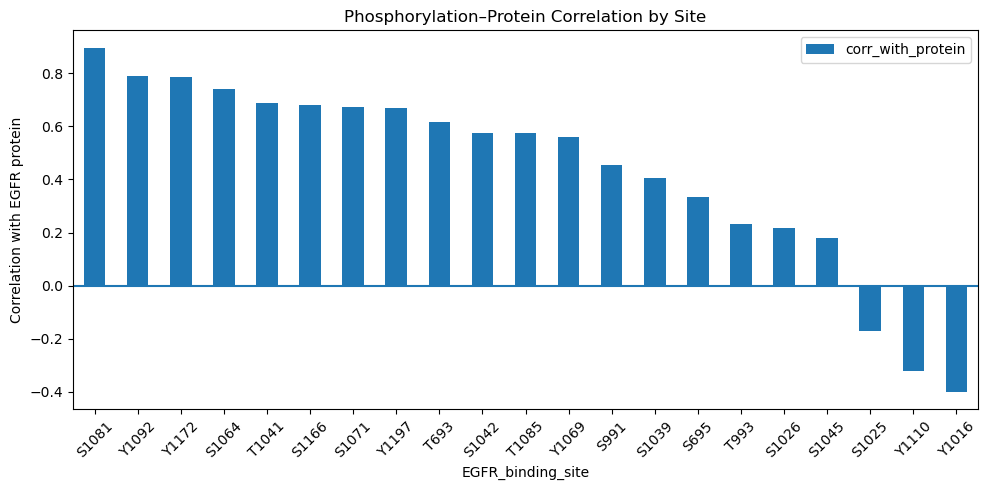

In [148]:
correlations.plot(
    x="EGFR_binding_site",
    y="corr_with_protein",
    kind="bar",
    figsize=(10,5)
)

plt.axhline(0)  # zero line
plt.ylabel("Correlation with EGFR protein")
plt.title("Phosphorylation–Protein Correlation by Site")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Some of the EGFR phosphorylation sites like Y112 and Y1069 has a strong correlation since it scale according to their receptor (rNA) expression, however, the Y110 while weak can show us potentional regulatory independent protein levels.

If they're scattered = behave independently


If they're clustered = co-regulate

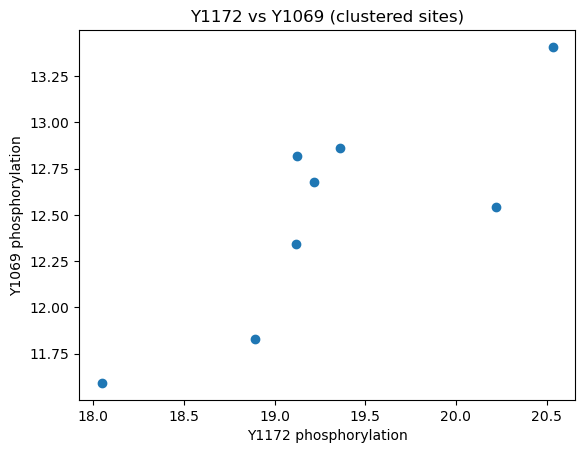

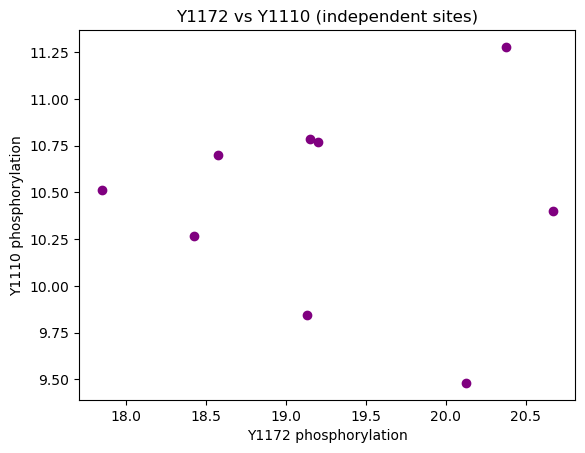

In [ ]:
target_sites= ["Y1172", "Y1069", "Y1110"]
subset = phospho_by_site[phospho_by_site["EGFR_binding_site"].isin(target_sites)]
#print(subset[["EGFR_binding_site", "EGFR_phospho_value"]])

#merging to compare binding sites (pivot = reshape= sites are columns)
pivot = subset.pivot_table(
    index="PATIENT_ID",
    columns="EGFR_binding_site",
    values="EGFR_phospho_value"
)
#need for id clusters
pivot_filled = pivot.apply(lambda col: col.fillna(col.mean()), axis=0)

plt.scatter(pivot["Y1172"], pivot["Y1069"])
plt.xlabel("Y1172 phosphorylation")
plt.ylabel("Y1069 phosphorylation")
plt.title("Y1172 vs Y1069 (clustered sites)")
plt.show()

plt.scatter(pivot["Y1172"], pivot["Y1110"], color='purple')
plt.xlabel("Y1172 phosphorylation")
plt.ylabel("Y1110 phosphorylation")
plt.title("Y1172 vs Y1110 (independent sites)")
plt.show()

c:\Users\anaso\ProjPy\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


<class 'sklearn.decomposition._pca.PCA'>


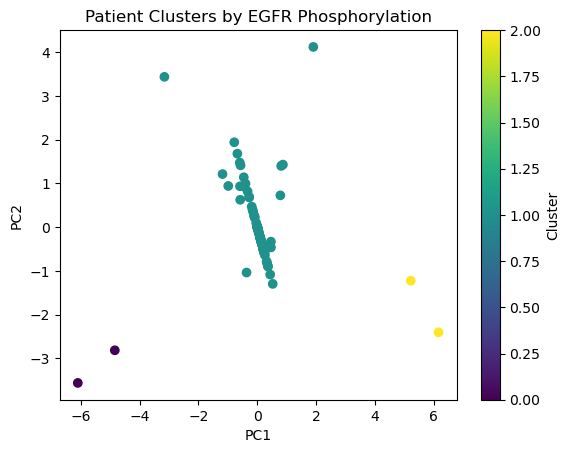

In [ ]:
#clustering/normalizing patients by phospho values
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(pivot_filled)

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

pivot_filled["cluster"] = clusters
#print(PCA) #sanity check

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Patient Clusters by EGFR Phosphorylation")
plt.colorbar(label="Cluster")
plt.show()

In [179]:
cluster_profiles = pivot_filled.groupby("cluster").mean()
print(cluster_profiles)

EGFR_binding_site      Y1069      Y1110      Y1172
cluster                                           
0                  12.507866   9.662529  19.631822
1                  12.527816  10.467165  18.938087
2                  11.709873  10.447540  18.469060


From the correlation matrix, we can see the high Y1069 and Y1172 in cluster 0 meaning it is EGFR-active!!

I also looked at the varience since the corr only depended on how the site is influenced by the protein but the varience can track the changes across common patients.

For signaling driven date, we ideally need a high varience and low corr

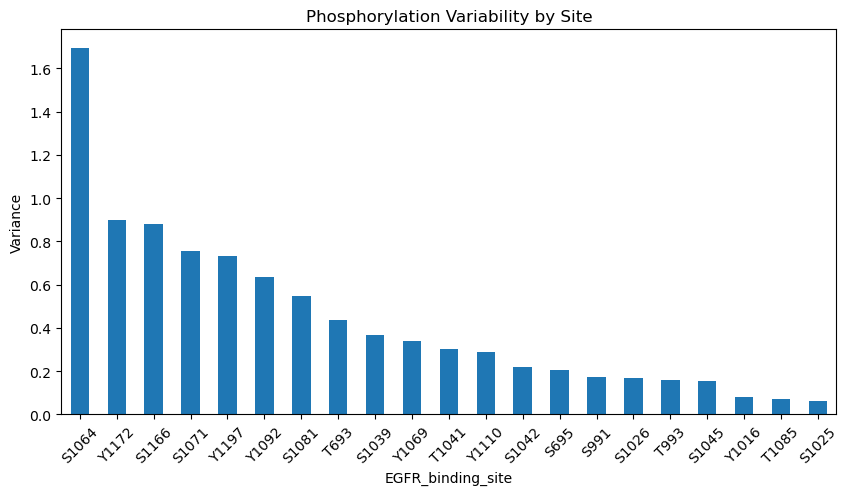

In [185]:
site_variance = (
    phospho_by_site
    .groupby("EGFR_binding_site")["EGFR_phospho_value"]
    .var()
    .sort_values(ascending=False)
)

#what sites change the most across patients?
#print(site_variance)
"""
important for ML
Y1172 has a high varience and high correlation!! 
"""
site_variance.plot(kind="bar", figsize=(10,5))
plt.ylabel("Variance")
plt.title("Phosphorylation Variability by Site")
plt.xticks(rotation=45)
plt.show()


Empty DataFrame
Columns: [site, corr_with_protein, variance]
Index: []


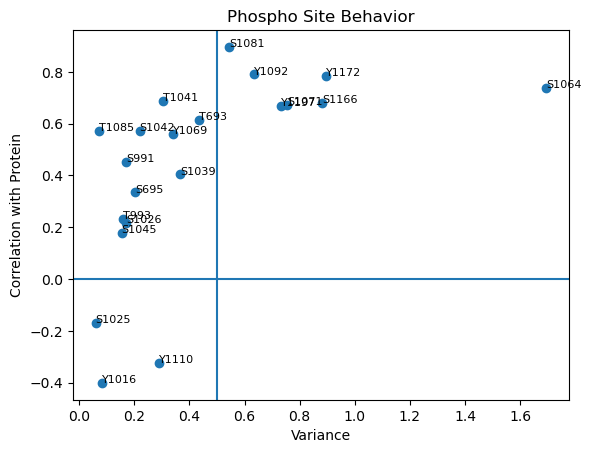

In [186]:
#comparison of corr and varience

merged_metrics = correlations.merge(
    site_variance.reset_index(),
    on="EGFR_binding_site"
)

merged_metrics.columns = ["site", "corr_with_protein", "variance"]

# Find most interesting sites
interesting = merged_metrics[
    (merged_metrics["variance"] > 0.5) &
    (merged_metrics["corr_with_protein"] < 0.5)
]

print(interesting.sort_values(by="variance", ascending=False))

plt.scatter(
    merged_metrics["variance"],
    merged_metrics["corr_with_protein"]
)

for i, row in merged_metrics.iterrows():
    plt.text(row["variance"], row["corr_with_protein"], row["site"], fontsize=8)

plt.xlabel("Variance")
plt.ylabel("Correlation with Protein")
plt.title("Phospho Site Behavior")

plt.axhline(0)
plt.axvline(0.5)

plt.show()

In [ ]:
#rNA to protein baseline
rna_protein = protein.merge(
    rna,
    on="PATIENT_ID"
)

corr_rna_protein = rna_protein["EGFR_RNA"].corr(rna_protein["EGFR_PROTEIN"])
print("RNA vs Protein correlation:", corr_rna_protein)

#high corr

RNA vs Protein correlation: 0.8357908175336242


In [188]:
#rNa to phospho analysis per site
phospho_rna = phospho_by_site.merge(
    rna[["PATIENT_ID", "EGFR_RNA"]],
    on="PATIENT_ID"
)

rna_phospho_corr = (
    phospho_rna
    .groupby("EGFR_binding_site")
    .apply(lambda df: df["EGFR_phospho_value"].corr(df["EGFR_RNA"]))
    .reset_index(name="corr_with_rna")
    .sort_values(by="corr_with_rna", ascending=False)
)

print(rna_phospho_corr)

   EGFR_binding_site  corr_with_rna
7              S1081       0.886119
19             Y1172       0.776417
12             T1085       0.741801
5              S1064       0.715412
17             Y1092       0.710030
20             Y1197       0.678891
8              S1166       0.651089
11             T1041       0.617821
13              T693       0.564401
6              S1071       0.524546
3              S1042       0.478226
2              S1039       0.448132
16             Y1069       0.434198
9               S695       0.394995
10              S991       0.365374
14              T993       0.170937
1              S1026       0.163273
4              S1045       0.066047
18             Y1110      -0.308275
0              S1025      -0.331130
15             Y1016      -0.354443


C:\Users\anaso\AppData\Local\Temp\ipykernel_14740\8895608.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: df["EGFR_phospho_value"].corr(df["EGFR_RNA"]))


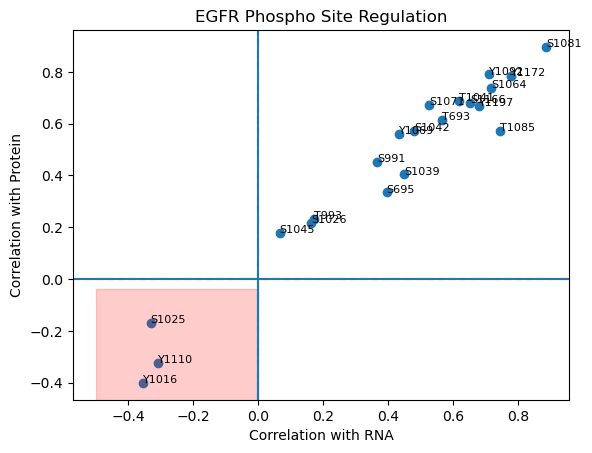

In [204]:
#egfr has nans so first compared correlations

#rna.protein.activity
combined = correlations.merge(
    rna_phospho_corr,
    on="EGFR_binding_site"
)

combined.columns = ["site", "corr_with_protein", "corr_with_rna"]

#print(combined)

"""
Is it EFGR signaling driven by expression(protein kinase based)?

correlation with rna = transcriptional
correlation with protein = translation
minimal corr = signaling regulation

What happens to each site? need to verify
shown in red, in the scatter plot, sites Y110 and Y1016 are likely signaling modulation nodes
"""

plt.scatter(
    combined["corr_with_rna"],
    combined["corr_with_protein"]
)

for i, row in combined.iterrows():
    plt.text(row["corr_with_rna"], row["corr_with_protein"], row["site"], fontsize=8)
plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")
plt.axvspan(-.5, 0, ymin=0, ymax=0.3, alpha=0.2, color = 'red')

plt.xlabel("Correlation with RNA")
plt.ylabel("Correlation with Protein")
plt.title("EGFR Phospho Site Regulation")

plt.axhline(0)
plt.axvline(0)

plt.show()

If the mutation.csv can show if the EGFR was mutated through L858R or exon 19 it can be indicator if the EGFR-mutated tumors show higher phospho activity?

Need to csv according to EGFR with CPTAC before modeling Binding Affinity